Importing The Dependencies

In [27]:
# Data handling & visualization
import pandas as pd
import numpy as np  # Import NumPy (previously missing)
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (Model Training & Evaluation)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor  # Add Random Forest for better performance
from sklearn import metrics  # Import metrics for evaluation

# Display settings
import warnings
warnings.simplefilter("ignore")  # Ignore warnings for cleaner output


Data Collection And Processing

In [28]:
# loading the data from csv file to pandas dataframe
df= pd.read_csv("car data.csv")
df


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [29]:
# checking the number of rows and columns
df.shape


(301, 9)

In [30]:
# getting some information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [31]:
# checking the number of missing values per column
print(df.isnull().sum())


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [32]:
# checking the distribution of categorical data
print(df.Fuel_Type.value_counts())  # Distribution of fuel types
print(df.Seller_Type.value_counts())  # Distribution of seller types
print(df.Transmission.value_counts())  # Distribution of transmission types


Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


Encoding the Categorical Data

In [33]:
# Encoding "Fuel_Type" Column
df.replace({'Fuel_Type': {'Petrol': 0, 'Diesel': 1, 'CNG': 2}}, inplace=True)

# Encoding "Seller_Type" Column
df.replace({'Seller_Type': {'Dealer': 0, 'Individual': 1}}, inplace=True)

# Encoding "Transmission" Column
df.replace({'Transmission': {'Manual': 0, 'Automatic': 1}}, inplace=True)

# Verify the changes
print(df.head())  # Display first few rows to check encoding


  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  \
0     ritz  2014           3.35           5.59       27000          0   
1      sx4  2013           4.75           9.54       43000          1   
2     ciaz  2017           7.25           9.85        6900          0   
3  wagon r  2011           2.85           4.15        5200          0   
4    swift  2014           4.60           6.87       42450          1   

   Seller_Type  Transmission  Owner  
0            0             0      0  
1            0             0      0  
2            0             0      0  
3            0             0      0  
4            0             0      0  


In [34]:
df.head()  # Displays the first 5 rows of the dataset


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


Splitting the data and Target

In [35]:
X = df.drop(['Car_Name', 'Selling_Price'], axis=1)  # Features
Y = df['Selling_Price']  # Target variable


In [36]:
print(X)


     Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1        0  
2        0  
3        0 

In [37]:
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


Splitting Training and Test data

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=2)

# Verify the split
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (270, 7)
Testing set size: (31, 7)


# Model Training

1. Linear **Regression**

In [39]:
# loading the linear regression model
lin_reg_model = LinearRegression()

In [40]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

**Model** Evaluation

In [41]:
# prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [42]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8799451660493711


Visualize the actual prices and Predicted prices

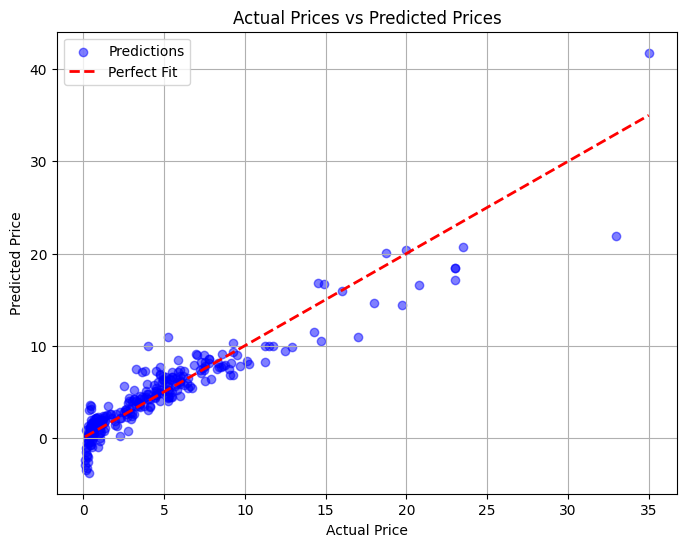

In [44]:
# Scatter plot
plt.figure(figsize=(8,6))  # Set figure size
plt.scatter(Y_train, training_data_prediction, color="blue", alpha=0.5, label="Predictions")  # Scatter points

# Add a reference line (ideal predictions where actual = predicted)
x = np.linspace(min(Y_train), max(Y_train), 100)  # Generate points for line
plt.plot(x, x, color="red", linestyle="--", linewidth=2, label="Perfect Fit")  # Diagonal reference line

# Labels and title
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()  # Add legend
plt.grid(True)  # Show grid for better readability
plt.show()



In [45]:
# prediction on Training data
test_data_prediction = lin_reg_model.predict(X_test)

In [46]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8365766715027051


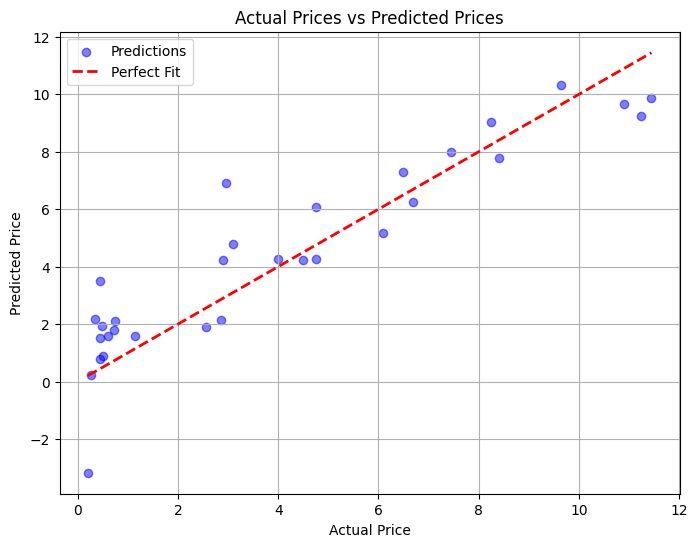

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, test_data_prediction, color="blue", alpha=0.5, label="Predictions")

x = np.linspace(min(Y_test), max(Y_test), 100)
plt.plot(x, x, color="red", linestyle="--", linewidth=2, label="Perfect Fit")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()


2. Lasso Regression

In [48]:
# loading the linear regression model
lass_reg_model = Lasso()

In [49]:
lass_reg_model.fit(X_train,Y_train)

Lasso()

**Model Evaluation**

In [50]:
# prediction on Training data
training_data_prediction = lass_reg_model.predict(X_train)

In [51]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8427856123435794


Visualize the actual prices and Predicted prices

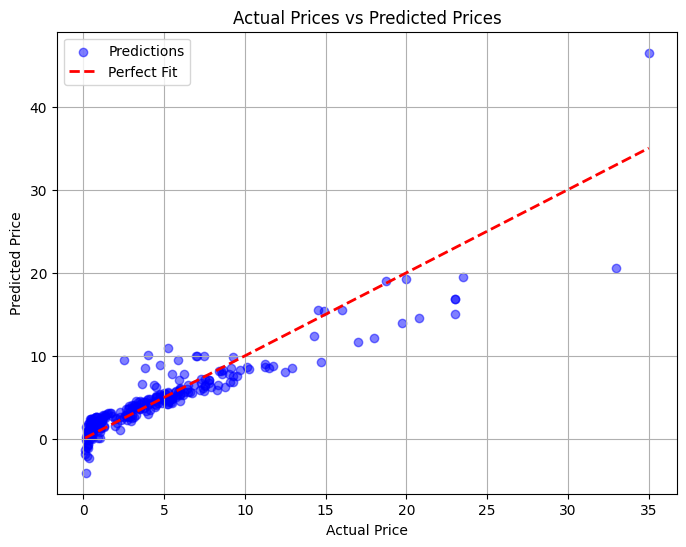

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(Y_train, training_data_prediction, color="blue", alpha=0.5, label="Predictions")

x = np.linspace(min(Y_train), max(Y_train), 100)
plt.plot(x, x, color="red", linestyle="--", linewidth=2, label="Perfect Fit")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()


In [53]:
# prediction on Training data
test_data_prediction = lass_reg_model.predict(X_test)

In [54]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8709167941173195


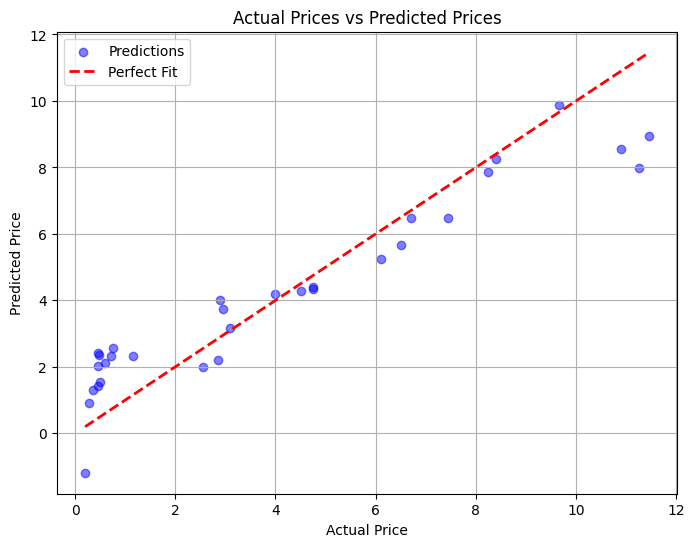

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, test_data_prediction, color="blue", alpha=0.5, label="Predictions")

x = np.linspace(min(Y_test), max(Y_test), 100)
plt.plot(x, x, color="red", linestyle="--", linewidth=2, label="Perfect Fit")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()
